In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Resolve project root relative to this notebook's location
_project_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__' if '__file__' in locals() else os.getcwd())))
_analysis_dir = os.path.join(_project_dir, "dev_logs", "analysis")

if _project_dir not in sys.path:
    sys.path.insert(0, _project_dir)
if _analysis_dir not in sys.path:
    sys.path.insert(0, _analysis_dir)

# 🛑 Self-healing reload guard
for key in list(sys.modules.keys()):
    if key.startswith('dev_logs.analysis') or key == 'graphics':
        del sys.modules[key]

from dev_logs.analysis.database.flight_loader import (
    load_flight_data,
    # ── Thin plot wrappers ──
    plot_trajectory_from,
    plot_velocity_profile_from,
    plot_battery_sag_from,
    plot_imu_dynamics_from,
    plot_imu_xyz_from,
    plot_actuators_from,
    plot_allocator_from,
    plot_pid_tracking_from,
    plot_full_loop_geometry_from,
    # ── EKF velocity ──
    compute_ekf_velocity,
    plot_ekf_velocity_from,
    plot_ekf_kinetic_from,
    plot_ekf_dual_comparison,
)

# Professional plotting style (thesis)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'figure.titlesize': 14,
    'figure.dpi': 150,
})

# ══════════════════════════════════════════════════════════════════════════
# Load representative flights ONCE — all plot cells reuse this data.
# ══════════════════════════════════════════════════════════════════════════

rot = load_flight_data(
    "flight_20260601-1756_45°_column_collision_loop_rotating_cage",
    "Pass-05"
)
# fix = load_flight_data(
#     "flight_20260529-1041_45°_column_collision_loop_fixed_cage",
#     "Pass-03"
# )
fix = load_flight_data(
    "flight_20260524-1904_75°_column_collision_loop_fixed_cage",
    "Pass-01"
)

## 🗺️ Full Mission Loop Geometry — 45° Collision

Theoretical top-down view of the complete collision loop, based on `ExpCollision45Deg` mission waypoints.  No flight data — only the design geometry.
Uses the same rotated coordinate system, canvas, drone rendering, and styling as `plot_trajectory()`.


In [ ]:
# ─── 🗺️  Full Loop Theoretical Geometry — 45° Column Collision ─────────

plot_full_loop_geometry_from(
    angle_deg=45,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/45° Column Collision Loop Full Mission Geometry.png",
)

## 📐 Interactive Analysis — Representative Flights (45°)

All plots are generated on-the-fly from raw MCAP data.  Nothing is written to disk or the database.
Each cell renders **both** conditions side-by-side: Rotating Cage (🥇) and Fixed Cage (🥇).


In [ ]:
# ─── 🗺️  2D Top-Down Trajectory ───────────────────────────────────────────

plot_trajectory_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage 2D Trajectory.png",
)
plot_trajectory_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage 2D Trajectory.png",
)

In [ ]:
# ─── 📊  Kinetic Profile (Raw MoCap, no spline) ───────────────────────────

plot_velocity_profile_from(
    rot, raw=True,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage Kinetic Profile (Raw).png",
)
plot_velocity_profile_from(
    fix, raw=True,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage Kinetic Profile (Raw).png",
)

### 🧭 EKF Kinetic Profile (Raw, no MoCap rate)

Same 2-panel layout as the raw MoCap kinetic profile, but using PX4 onboard
EKF (vehicle_odometry) velocity instead of MoCap-derived velocity.
Tangential acceleration is computed by finite-difference of the EKF speed.
The MoCap rate panel is omitted — EKF runs at a steady IMU rate, so rate
dropouts are not a concern.

In [ ]:
# ─── 🧭  Kinetic Profile (EKF velocity + Tangential Accel) ───────────

plot_ekf_kinetic_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage EKF Kinetic Profile.png",
)
plot_ekf_kinetic_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage EKF Kinetic Profile.png",
)

In [ ]:
# ─── 📊  Kinetic Profile (Splined) ────────────────────────────────────────

plot_velocity_profile_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage Kinetic Profile (Splined).png",
)
plot_velocity_profile_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage Kinetic Profile (Splined).png",
)

### 🧭 EKF Velocity Viewer — PX4 Onboard Odometry vs MoCap-Derived Velocity

The PX4 EKF fuses MoCap position + IMU acceleration at 100–250 Hz.
For the Fixed Cage (severe MoCap dropouts), EKF velocity is inherently smooth —
no dropout kinks to filter out.


In [ ]:
# ─── 🧭  EKF vs MoCap Velocity (Representative Fixed Cage) ────────────────
# EKF shines here — MoCap rate drops to ~10 Hz but EKF fills gaps with IMU.

plot_ekf_velocity_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage EKF vs MoCap Velocity.png",
)

# 🔄  Rotating Cage (uncomment to compare):
# plot_ekf_velocity_from(
#     rot,
#     output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage EKF vs MoCap Velocity.png",
# )

In [ ]:
# ─── 🧭  EKF Dual Comparison (Fixed vs Rotating Cage, side by side) ───────

plot_ekf_dual_comparison(
    rot, fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/EKF Dual Comparison Fixed vs Rotating.png",
)

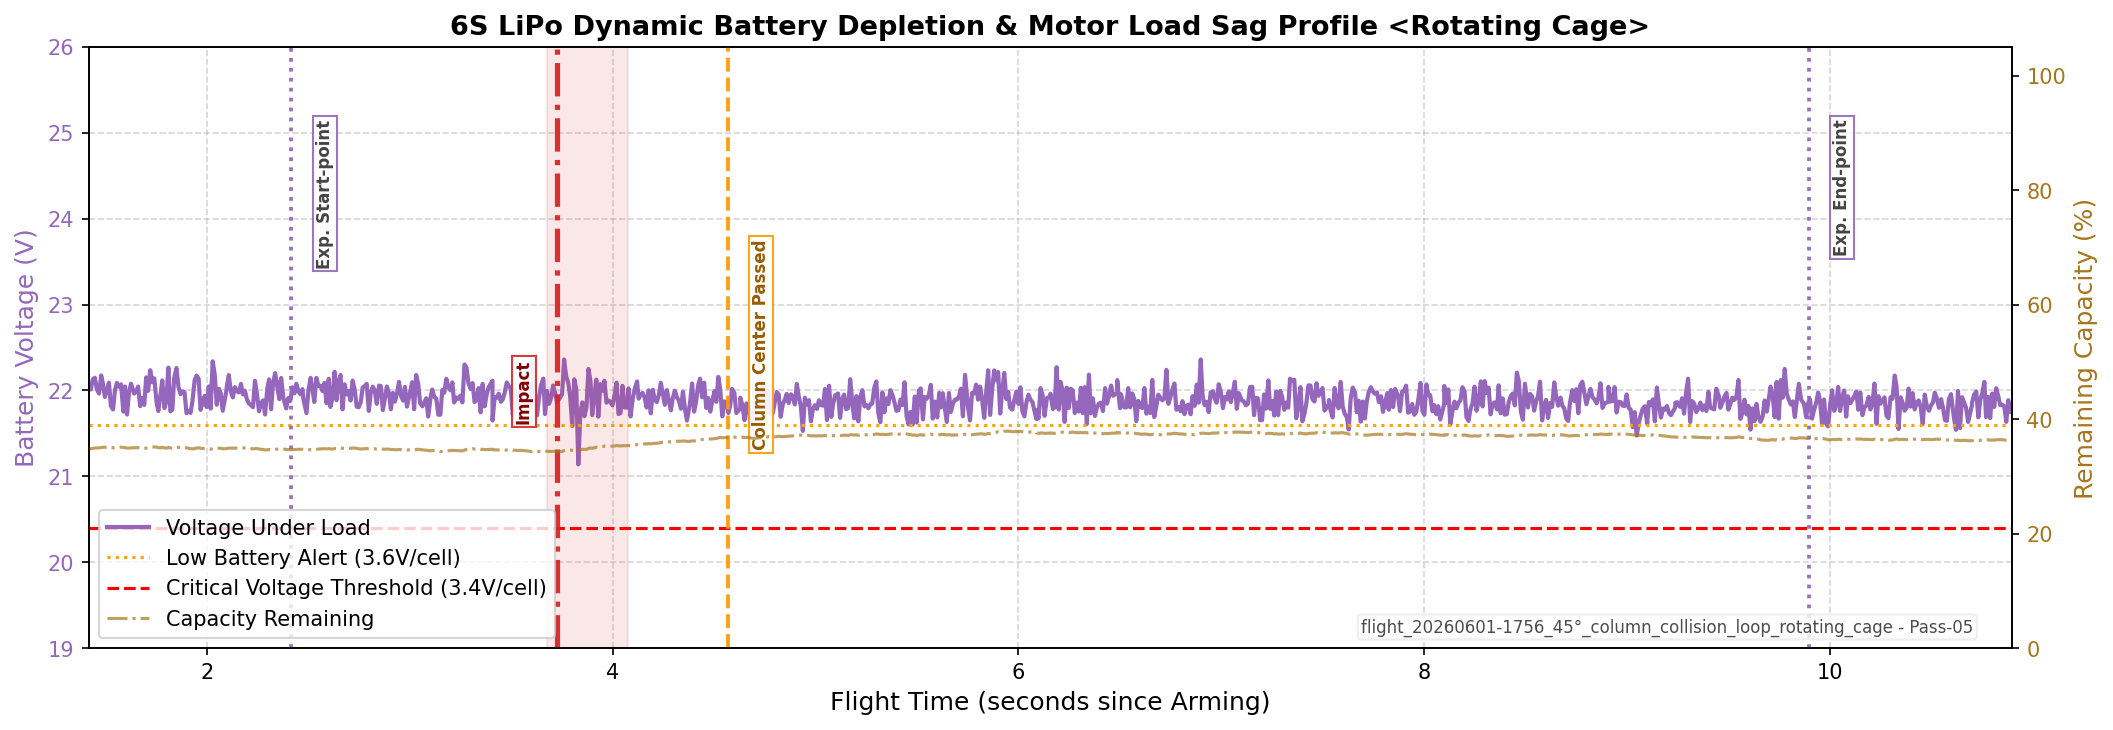

🔋 Battery Chemical Consumption Analysis (Rotating Cage):
   - Initial Unloaded Voltage:           21.88 V
   - Minimum Voltage Sag (Takeoff/Loads): 21.14 V  (Total Drop = -0.74 V)
   - Active Flight Duration Recorded:     10.9 seconds
   - Total Capacity Consumption:          -1.1%
   - Consumption Rate (load-adjusted):     -6.0% capacity per minute of flight


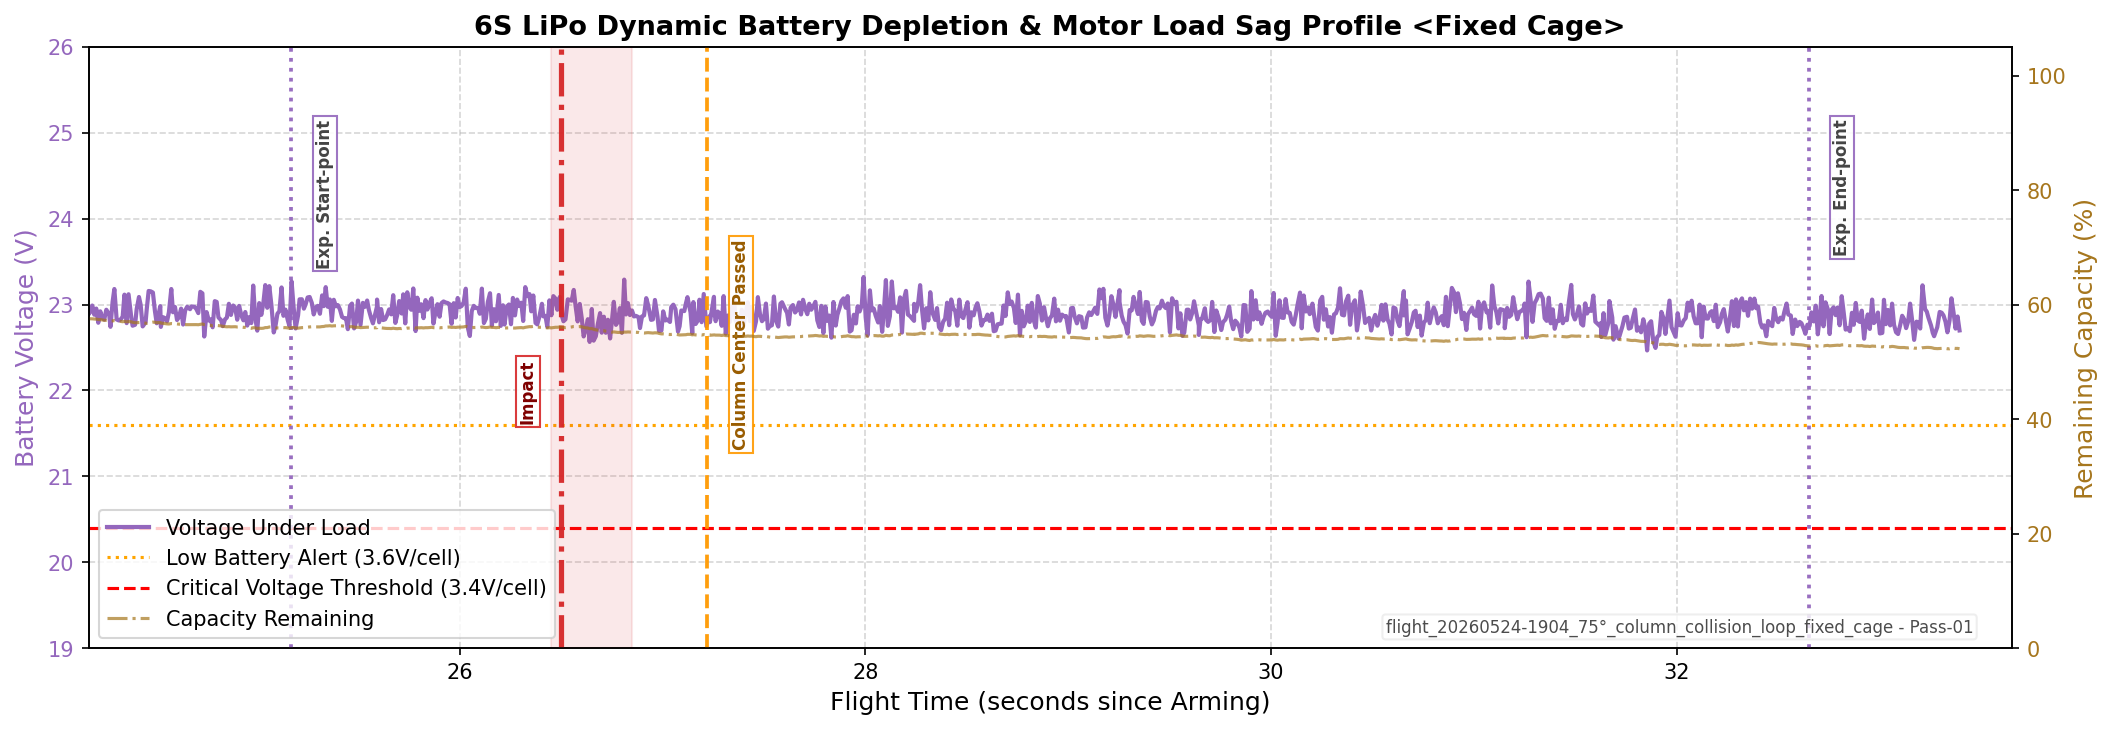

🔋 Battery Chemical Consumption Analysis (Fixed Cage):
   - Initial Unloaded Voltage:           23.38 V
   - Minimum Voltage Sag (Takeoff/Loads): 22.47 V  (Total Drop = -0.91 V)
   - Active Flight Duration Recorded:     29.0 seconds
   - Total Capacity Consumption:          34.9%
   - Consumption Rate (load-adjusted):     72.2% capacity per minute of flight
   - Safe Flight Ceiling (40% Cutoff):    2.0 seconds


In [9]:
# ─── 🔋  Battery Voltage Sag ──────────────────────────────────────────────

plot_battery_sag_from(rot)
plot_battery_sag_from(fix)


In [ ]:
# ─── 📈  IMU Collision Dynamics (accel deviation + gyro surge) ────────────

plot_imu_dynamics_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage IMU Collision Dynamics.png",
)
plot_imu_dynamics_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage IMU Collision Dynamics.png",
)

In [ ]:
# ─── 📐  IMU XYZ Raw Components (RGB-standard) ────────────────────────────

plot_imu_xyz_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage IMU XYZ Components.png",
)
plot_imu_xyz_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage IMU XYZ Components.png",
)

### ⚙️ PX4 ULog Plots (Motor Actuators, Control Allocation, PID Tracking)

These require a `.ulg` file alongside the MCAP in the flight capsule directory.


In [ ]:
# ─── ⚙️  Actuator Motor Commands & Outputs ────────────────────────────────

plot_actuators_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage Actuator Commands.png",
)
plot_actuators_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage Actuator Commands.png",
)

In [ ]:
# ─── ❌ Control Allocator Saturation — REMOVED ──────────────────────────
# This plot showed nothing beyond what the actuator commands plot already
# covers (same data, same saturation events). Retired 2026-06-12.

In [ ]:
# ─── 🎛️  PID Rate Controller Tracking Performance ─────────────────────────

plot_pid_tracking_from(
    rot,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Rotating Cage PID Tracking.png",
)
plot_pid_tracking_from(
    fix,
    output_path="/home/dorten/MasterThesisDrone/thesis/plots/Fixed Cage PID Tracking.png",
)